### Demonstrate <strong>phase kickback</strong>

In [ ]:
!pip install -q qiskit-aer

Imports

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

Preparing execution backend

In [3]:
backend = AerSimulator(device='CPU')

Preparing circuit

In [ ]:
qc = QuantumCircuit(2,2)
qc.x(1)
qc.h(0)
qc.h(1)
qc.cx(0, 1) # Here the 'controller' qubit faces phase kickback and changes it's value from |+> to |-> while the 'controlled' qubit has no change
qc.h(0)
qc.h(1)
qc.measure(0, 0)
qc.measure(1, 1)
qc.draw()

┌───┐          ┌───┐┌─┐   
q_0: ┤ H ├───────■──┤ H ├┤M├───
     ├───┤┌───┐┌─┴─┐├───┤└╥┘┌─┐
q_1: ┤ X ├┤ H ├┤ X ├┤ H ├─╫─┤M├
     └───┘└───┘└───┘└───┘ ║ └╥┘
c: 2/═════════════════════╩══╩═
                          0  1

Transpile

In [20]:
tqc = transpile(qc, backend)

Execution

In [23]:
job = backend.run(tqc, shots=100)

Measurement Counts: {'11': 100}


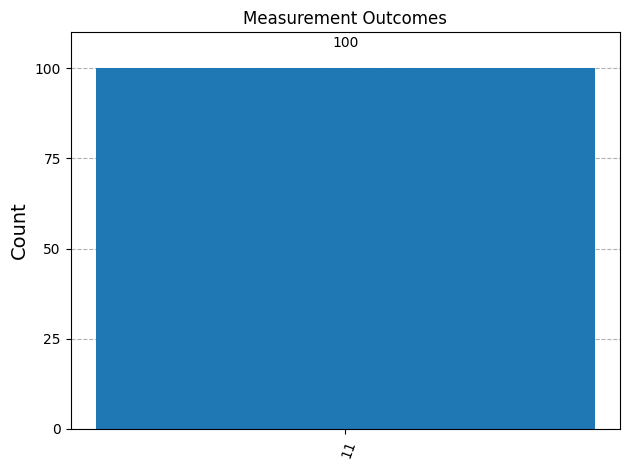

In [24]:
result = job.result()
counts = result.get_counts(tqc)

print("Measurement Counts:", counts)

plot_histogram(counts, title='Measurement Outcomes')